### Manfred Clase, Siri Strøm, Petrea Norgren

### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

In [19]:
import numpy as np
import pandas as pd

def generate_data(epsilon=2, N=1050, print_info=True, p=0.3):

    y = np.random.rand(N)
    y = (y < p).astype(int)
    if print_info:
        print('Sample size: ', N)
        print('Number of y in class 1: ', np.sum(y))
        print('Number of y in class 0: ', N - np.sum(y))


    epsilon = epsilon
    m0 = np.array([0, 0]) #Mean of class 0
    m1 = np.array([epsilon, 0]) #Mean of class 1
    cov0 = np.eye(2)*0.5
    cov1 = np.eye(2)*0.4

    X = np.zeros((N, 2))

    for i in range(N):
        if y[i] == 0:
            X[i] = np.random.multivariate_normal(mean=m0, cov=cov0)
        else:
            X[i] = np.random.multivariate_normal(mean=m1, cov=cov1)

    test = pd.DataFrame(np.concatenate([X, y.reshape(-1, 1)], axis=1), columns=['x0', 'x1', 'y'])

    test_idx = np.random.choice(N, size=1000, replace=False)

    test_data = test.iloc[test_idx]
    train_data = test.drop(test_idx)

    if print_info:
        print('Train data size: ', len(train_data))
        print('Test data size: ', len(test_data))
        print(train_data.head())
        print(test_data.head())
    return train_data, test_data

train_data, test_data = generate_data(epsilon=2, N=1050, print_info=True)


Sample size:  1050
Number of y in class 1:  295
Number of y in class 0:  755
Train data size:  50
Test data size:  1000
          x0        x1    y
9  -0.346631 -0.119635  0.0
12  2.260155  0.273786  1.0
13  0.040423 -1.069078  0.0
33 -1.269936 -0.637312  0.0
58  0.381132  0.862696  0.0
           x0        x1    y
447  0.110378 -1.465167  0.0
668  0.721447 -0.371662  0.0
913  1.453610  0.686707  1.0
933  0.439712 -1.017991  0.0
478 -0.563813  0.147292  0.0


**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

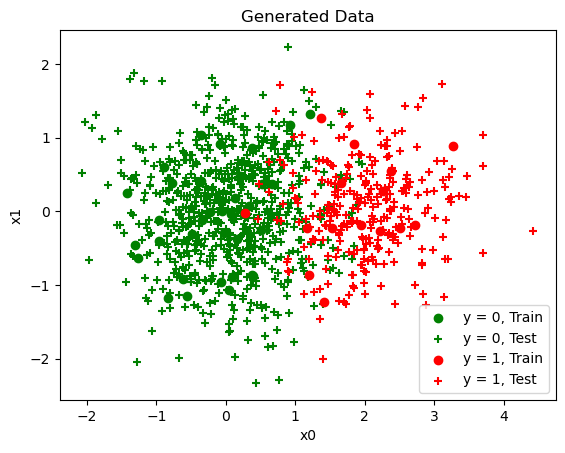

In [20]:
import matplotlib.pyplot as plt

color = ['green', 'red']
for i in range(2):
    plt.scatter(train_data[train_data['y'] == i]['x0'], train_data[train_data['y'] == i]['x1'], label=f'y = {i}, Train', marker='o', color=color[i])
    plt.scatter(test_data[test_data['y'] == i]['x0'], test_data[test_data['y'] == i]['x1'], c=color[i], label=f'y = {i}, Test', marker='+' )
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('Generated Data')
plt.legend()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The optimal bayes classifier is mathematically defined as: $f(x_0) = argmax_{k = \{0,1\}} Prob \left (Y=k | \mathbf{X} \in \Beta_\varepsilon(x_0)\right)$ 


$f(x_0) = 1$ if $\frac{Prob \left (Y=1 | \mathbf{X} \in \Beta_\varepsilon(x_0)\right)}{Prob \left (Y=0 | \mathbf{X} \in \Beta_\varepsilon(x_0)\right)}> 1$ else $f(x_0) = 0$. 
Boundary: $\frac{Prob \left (Y=1 | \mathbf{X} \in \Beta_\varepsilon(x_0)\right)}{Prob \left (Y=0 | \mathbf{X} \in \Beta_\varepsilon(x_0)\right)} = 1$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

`Assumption:` We assumed that the question actually means the previously defined dataset $\mathcal{D}(10^3 \mid 2, 0.3)$ and not that we should generate a new one

### Answer:
The error is expected to go down as the distance between the classes increase due to the easier separation

Generating data with epsilon = 0.1
Generating data with epsilon = 0.6
Generating data with epsilon = 1.1
Generating data with epsilon = 1.6
Generating data with epsilon = 2.1
Generating data with epsilon = 2.6
Generating data with epsilon = 3.1
Generating data with epsilon = 3.6
Generating data with epsilon = 4.1
Generating data with epsilon = 4.6
Generating data with epsilon = 5.1
Generating data with epsilon = 5.6
Generating data with epsilon = 6.1
Generating data with epsilon = 6.6
Generating data with epsilon = 7.1
Generating data with epsilon = 7.6
Generating data with epsilon = 8.1
Generating data with epsilon = 8.6
Generating data with epsilon = 9.1
Generating data with epsilon = 9.6


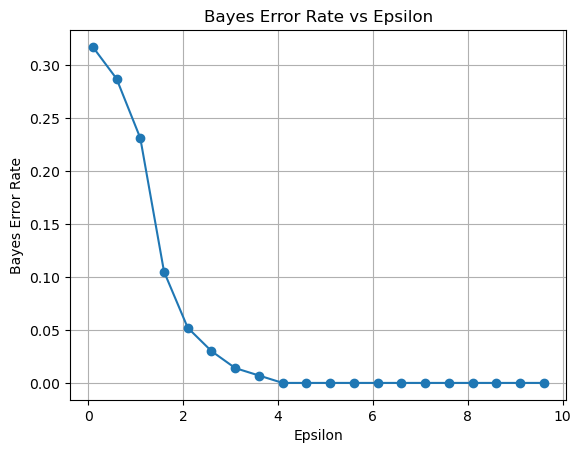

In [21]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted, validate_data


class BayesPredictor(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.m0 = None
        self.m1 = None
        self.cov0 = None
        self.cov1 = None
        self.p = None
        

    def fit(self, X, y):
        # Check that X and y have correct shape, set n_features_in_, etc.
        X, y = validate_data(self, X, y)
        self.X_ = X
        self.y_ = y
        # Return the classifier
        self.m0 = np.mean(X[y == 0], axis=0)
        self.m1 = np.mean(X[y == 1], axis=0)
        #self.cov0 = np.cov(X[y == 0].T)
        self.cov0 = np.diag(np.var(X[y==0], axis=0))
        self.cov1 = np.diag(np.var(X[y==1], axis=0))
        #self.cov1 = np.cov(X[y == 1].T)
        self.p = np.mean(y)
        return self

    def predict(self, X):
        # Check if fit had been called
        check_is_fitted(self)
        # Input validation
        X = validate_data(self, X, reset=False)
        
        # Compute the likelihoods for both classes
        from scipy.stats import multivariate_normal
        
        likelihood0 = multivariate_normal.pdf(X, mean=self.m0, cov=self.cov0) * (1 - self.p)
        likelihood1 = multivariate_normal.pdf(X, mean=self.m1, cov=self.cov1) * self.p
        
        # Predict class labels based on which likelihood is higher
        return (likelihood1 > likelihood0).astype(int)

epsilons = np.arange(0.1, 10, 0.5)
Bayes_error_rates = np.zeros(len(epsilons))

for i in range(len(epsilons)):
    print(f'Generating data with epsilon = {epsilons[i]}')
    train_data, test_data = generate_data(epsilon=epsilons[i], N=1050, print_info=False)
    bc = BayesPredictor()
    bc.fit(train_data[['x0', 'x1']].values, train_data['y'].values)
    Bayes_error_rates[i] = np.mean(bc.predict(test_data[['x0', 'x1']].values) != test_data['y'].values)
    
plt.plot(epsilons, Bayes_error_rates, marker='o')
plt.xlabel('Epsilon')
plt.ylabel('Bayes Error Rate')
plt.title('Bayes Error Rate vs Epsilon')
plt.grid()
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

`Answer` Since the covariance matrices of the two datasets is not equal to eachother LDA would be considered inapproriate because LDA assumes these to be equal. QDA does not make this assumption and therefore is the better option in this case.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

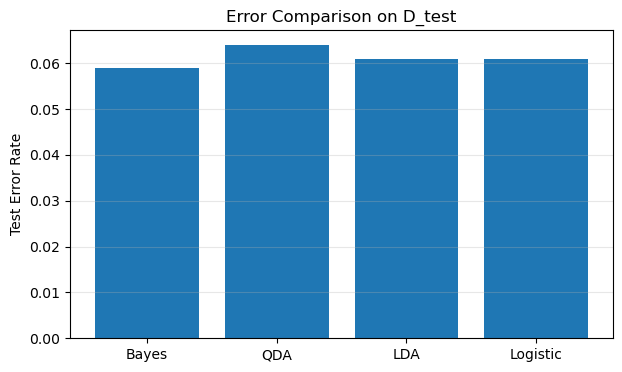

Bayes   : 0.0590
QDA     : 0.0640
LDA     : 0.0610
Logistic: 0.0610


In [22]:
# Clean (e) comparison plot: Bayes, QDA, LDA, Logistic on current D_train / D_test

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

train_data, test_data = generate_data(epsilon=2, N=1050, print_info=False)

X_train = train_data[['x0', 'x1']].values
y_train = train_data['y'].values.astype(int)
X_test = test_data[['x0', 'x1']].values
y_test = test_data['y'].values.astype(int)

lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
logistic = LogisticRegression(max_iter=1000).fit(X_train, y_train)
bayes = BayesPredictor().fit(X_train, y_train)

errors = {
    'Bayes': np.mean(bayes.predict(X_test) != y_test),
    'QDA': np.mean(qda.predict(X_test) != y_test),
    'LDA': np.mean(lda.predict(X_test) != y_test),
    'Logistic': np.mean(logistic.predict(X_test) != y_test),
}

plt.figure(figsize=(7, 4))
plt.bar(list(errors.keys()), list(errors.values()))
plt.ylabel('Test Error Rate')
plt.title('Error Comparison on D_test')
plt.grid(axis='y', alpha=0.3)
plt.show()

for k, v in errors.items():
    print(f'{k:8s}: {v:.4f}')

`Answer:` Bayes classifier makes correct assumption that x1 and x2 are un-correlated, QDA does not make such an assumption. LDA and Logistic Regression is restricted to linear decision boundary which is a restriction. As the training set size the QDA's non-assumption of equal covariance matrices for both classes will cause QDA to outperform LDA. Logistic regression does not make the correct assumption that the data is gaussian which is another limitation of its performance, especially for smaller N's.

As the training dataset increases the estimation of the distributions perfomed by Bayes and the non-linear decision boundary in QDA will result in a better performance than LDA and logistic regression.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

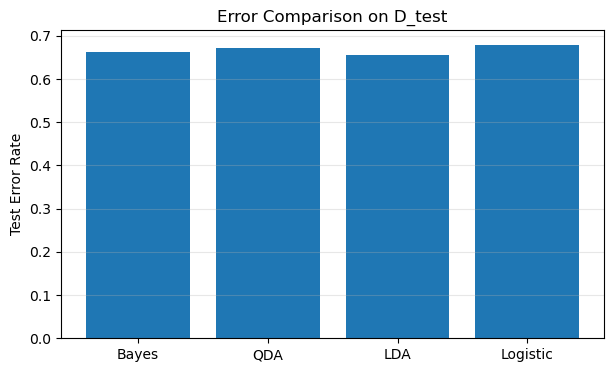

Bayes   : 0.6630
QDA     : 0.6710
LDA     : 0.6550
Logistic: 0.6790


In [23]:

# (e): train on D_train and evaluate on D_test (single dataset)

_, test_data = generate_data(epsilon=0.5, N=1050, print_info=False, p=0.7)

# X_train = train_data[['x0', 'x1']].values
# y_train = train_data['y'].values.astype(int)
X_test = test_data[['x0', 'x1']].values
y_test = test_data['y'].values.astype(int)

# # lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
# # qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
# # logistic = LogisticRegression(max_iter=1000).fit(X_train, y_train)
# # bayes = BayesPredictor().fit(X_train, y_train)

errors = {
    'Bayes': np.mean(bayes.predict(X_test) != y_test),
    'QDA': np.mean(qda.predict(X_test) != y_test),
    'LDA': np.mean(lda.predict(X_test) != y_test),
    'Logistic': np.mean(logistic.predict(X_test) != y_test),
}

plt.figure(figsize=(7, 4))
plt.bar(list(errors.keys()), list(errors.values()))
plt.ylabel('Test Error Rate')
plt.title('Error Comparison on D_test')
plt.grid(axis='y', alpha=0.3)
plt.show()

for model_name, err in errors.items():
    print(f'{model_name:8s}: {err:.4f}')


## Answer
The model was fitted on the training data generated on the following distribution $\mathcal{D}(50 \mid 2, 0.3)$. It was then tested on data generated from this $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Therefore the model is fitted on data that was fundamentally different from the test data and all models performes catastrophically (worse than random guess).

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


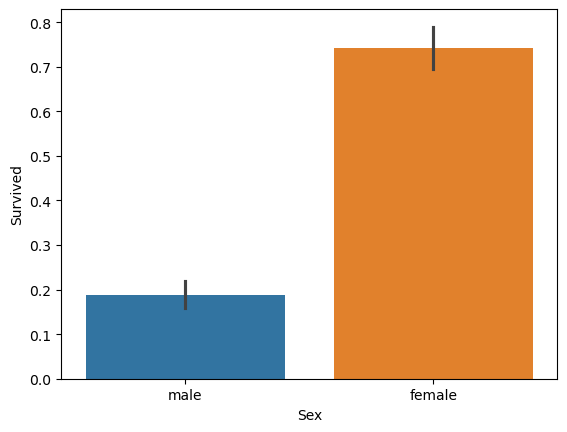

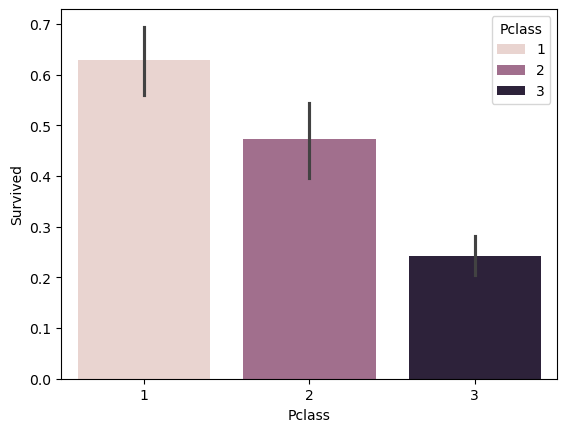

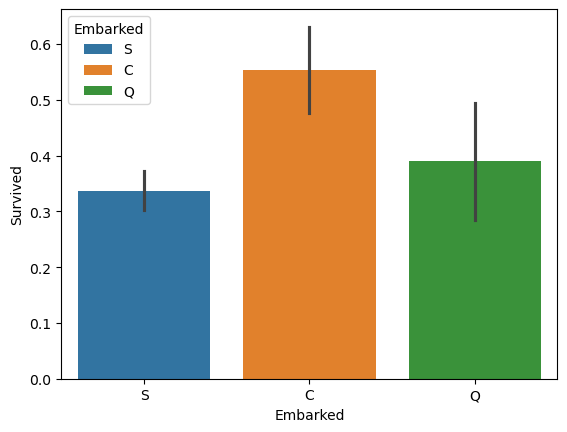

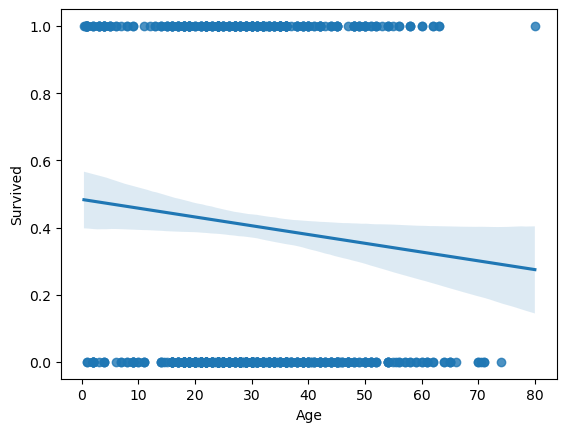

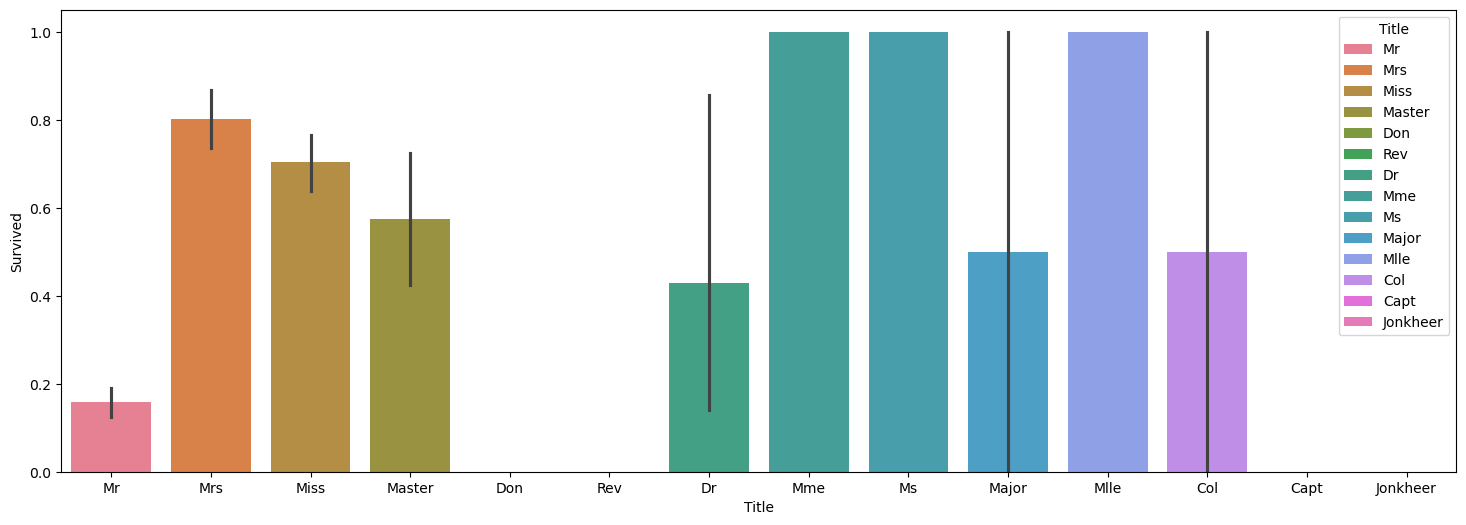

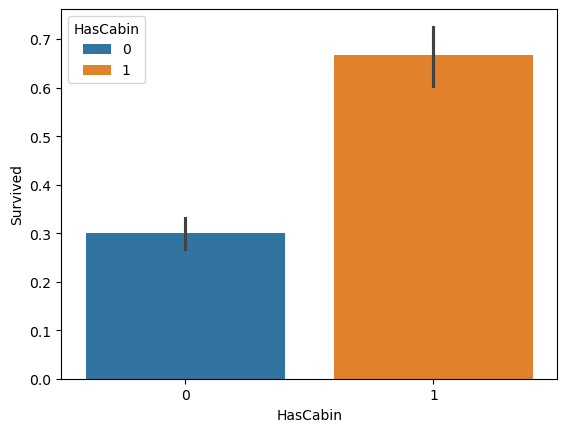

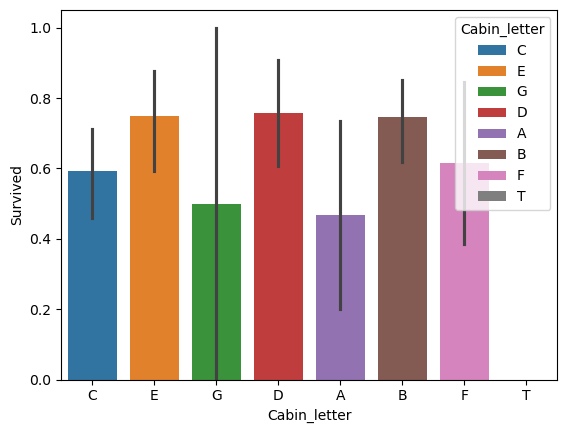

In [24]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic_train.csv")
X_train = df.drop(columns=['Survived'])
y_train = df['Survived']
X_test = pd.read_csv("titanic_test.csv")
data = X_train.copy()
data['Survived'] = y_train

print(df.isnull().sum())


sns.barplot(x='Sex', y='Survived', data=data, hue='Sex')
plt.show()
sns.barplot(x = "Pclass", y = "Survived", data = data, hue='Pclass')
plt.show()
sns.barplot(x = "Embarked", y = "Survived", data = data, hue='Embarked')
plt.show()
sns.regplot(x = "Age", y = "Survived", data = data)
plt.show()
data["Title"] = data["Name"].str.split(" ").str[1]
data["Title"] = data["Title"].str.extract(r'([A-Za-z]+)\.')
plt.figure(figsize = (18,6))
sns.barplot(x = "Title", y = "Survived", data = data, hue='Title')
plt.show()
data["HasCabin"] = data["Cabin"].notna().astype(int)
sns.barplot(x = "HasCabin", y = "Survived", data = data, hue='HasCabin')
plt.show()
data["Cabin_letter"] = data["Cabin"].str[0]
sns.barplot(x = "Cabin_letter", y = "Survived", data = data, hue='Cabin_letter')
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

def preprocess(data_in):
    data = data_in.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
    
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

    # Convert categorical variables to dummy/indicator variables
    data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

    return data

def feature_engineering(data_in):
    df = data_in.copy()

    df["Title"] = df["Name"].str.split(" ").str[1]
    df["Title"] = df["Title"].str.extract(r'([A-Za-z]+)\.') 
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don','Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    df["Cabin_letter"] = df["Cabin"].str[0]
    
    df = preprocess(df)
    
    df["FareBand"], bins = pd.qcut(df["Fare"], 4, labels=[1,2,3,4], retbins=True)
    df = pd.get_dummies(df, columns=['Title'], drop_first=True)
    df = pd.get_dummies(df, columns=['Cabin_letter'], drop_first=True)
    df["Age_bucket"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]) 
    
    return df

X_train_processed = feature_engineering(X_train)
X_test_processed = feature_engineering(X_test)
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='left', axis=1, fill_value=0)
clf = RandomForestClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train_processed, y_train, cv=cv, scoring='accuracy')
print(f"CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

clf.fit(X_train_processed, y_train.values.ravel())

y_pred = clf.predict(X_test_processed)


CV accuracy: 0.828 ± 0.026


In [26]:
from skrub import tabular_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

df = pd.read_csv("titanic_train.csv")
X = df.drop(columns=['Survived'])
y = df['Survived']

model = tabular_pipeline('classifier')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f"CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# Fit and predict
model.fit(X, y)
test_df = pd.read_csv("titanic_test.csv")
y_pred = model.predict(test_df)

CV accuracy: 0.818 ± 0.021


In [27]:
test_df = pd.read_csv("titanic_test.csv")
test_ids = test_df["PassengerId"]

submission = pd.DataFrame({"PassengerId": test_ids, "Survived": y_pred})

submission.to_csv("submission.csv", index=False)

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

## Answer

We tried two different approaches, one manual pipeline and one where we used tabular_pipeline from skrub. 
The manual pipeline made new features Title, HasCabin and Cabin_letter from Name and Cabin. It also filled in any missing ages with the median, and encoded categorical variables. 
Skrub does all of this plus it keeps features like Name and Cabin that we decided to drop in our manual pipeline, using GapEncoder to automatically find patterns.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

We ended up using skrub tabular_pipeline as it gave us a better result in the cross-validation, it also gave the best accuracy score on the Kaggle competition. The public leaderboard score from this was 0.811 whilst the highest from manual preprocessing and feature engineering was 0.761. Setting estimator to "classifier" in skrubs results in a Histogram-based Gradient Boosting Classification Tree. 